# Tutorial: Data Model

First, let's get some basic imports out of the way:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import smfbursts as smf

## Introduction to smfBursts structure

The goal of smfBursts is to remove as much "boiler plate" code as possible, 
while exposing all relevant parameters used in analysis of single molecule data.
This is done with using a *datamodel*.
We will start with a whirlwind introduction to this datamodel, and then go through each concept in much more detail.

smfBursts provides a set of fundamental classes that define dataprocessing piplines used to create data organized into tables.
The instructions for the processing come in the form of `smf.Param` objects, 
and the raw/base data is stored in `smf.datamodel.tables.DataSet` objects.
Processed `smf.datamodel.tables.Table` objects store the processed data created 
from the raw data in `smf.datamodel.tables.DataSet` objects and the instructions in `smf.Param` objects.
Different types of analysis are defined by subclasses of `smf.datamodel.tables.Table` 
(i.e. `smf.datamodel.tables.Table` functions as an abstract base class).

Each `smf.datamodel.tables.Table` looks at some sort of "datapoint", for instance a burst event (the primary type of "row" in single molecule analysis).
`smf.datamodel.tables.Table` subclasses define a set of columns, different types of measurments/values that can be assigned to each datapoint.
There are two main types of `smf.datamodel.tables.Table`: `smf.datamodel.tables.BaseTable` and `smf.datamodel.tables.ChildTable`. 
Subclasses of `smf.datamodel.tables.BaseTable` define a new set of datapoints (new rows).
`smf.datamodel.tables.BaseTable`s perform some sort of analysis that identifies new datapoints, and some initial columns.
Subclasses of `smf.datamodel.tables.ChildTable` add more columns to tables defined by a `smf.datamodel.tables.BaseTable`.
`smf.datamodel.tables.ChildTable`s perform some sort of additional analysis on the base data.

`smf.Column` objects take a `smf.Param` and specify a particular column within the table that would result from the instructions of said `smf.Param`.

Oftentimes in data analysis, it is useful to look at subsets of the data based on a given condition or set of conditions.
This fundamental idea has been called different things such as gates, masks, or filters, in various fields and by different individuals.
smfBursts has chosen the "gate" nomenclature, as in flow cytometry.
This is done using `smf.GateGroup` objects.

The process for defining these gates involved 3 types of objects: `smf.Column`, `smf.Gate` and `smf.GateGroup` objects.

The `smf.Column` object is used to define which column in which parameter value to access for creating the gate.\
The `smf.Gate` object is used to define a gate based on one or more `smf.Column`(s),
a function (e.g. $<$, $>$, inside ellipse etc.), and function values (like thresholds).\
The `smf.GateGroup` creates gates derived from logical operations on `smf.Gate` objects.
When defining the rows of output, `smf.Gate` objects are *always* wrapped in `smf.GateGroup` objects

At it's core `smf.datamodel.tables.DataSet` and `smf.datamodel.tables.Table` objects store actual data, while `smf.Param`, `smf.Column`, `smf.Gate` and `smf.GateGroup` objects are instructions.

### Sumary

| Instructions    | Data                           | Comments                                                                                           |
|-----------------|--------------------------------|----------------------------------------------------------------------------------------------------|
|                 | `smf.datamodel.tables.DataSet` | base data being analyzed                                                                           |
| `smf.Param`     | `smf.datamodel.tables.Table`   | group of processed data with specific number of entries (rows), defined by DataSet and Param       |
| `smf.Column`    | numpy array                    | a particular parameter, representable as a column in a table (has size of number of rows in table) |
| `smf.Gate`      | boolean mask                   | selection (aka mask aka gate) of rows                                                              |
| `smf.GateGroup` | boolean mask                   | Logical operation using several gates, defines set of rows                                         |

### `smf.Param` objects

A `smf.Param` object provides all the instructions for defining a `smf.datamodel.tables.Table`, which stores processed values.

`smf.Param`s require 3 pieces of information:
1. The `tp` (short for type): a `smf.datamodel.tables.Table` *type* (the class, **not** an instance thereof)
   (the "type" of parameter/table being defined, or what the `smf.Param` is "based" on).
3. The `params` (the *parameters*), supplied as a dictionary, the names of the keys and types of the values are determined by the table on which the param is based.
4. The `parents`, a dictionary defining on what `smf.Param`(s) the current `smf.Param` depends, similarly, the keys an `tp` of the values values are defined by the overall table type.

Let's introduce a `smf.datamodel.BaseTable` and what it requires when creating a `smf.Param` based on it:

#### `smf.Param` objects with `smf.Periods` tp 

The `smf.Periods` type divides the duration of a `smf.photondata.PhotonData` measurement into consecutive periods.

The `smf.Periods` type is a `smf.datamodel.tables.BaseTable` meaning that it establishes a new table.

##### `smf.Periods` params:

- detdef : a special object specifying the number of streams in each category (excitaion, emission, polarization, split),
  all `smf.photondata.PhotonData` objects specify this in their `smf.photondata.PhotonData.detdef` attribute.
- period : the duration of a single time interval.
- start_at : string defining how to set start time of first period, can be 'time_min', 'under', 'over', or 'zero'.
- stop_at : a string defining how to set stop time of last period, can be 'over' or 'under'.

##### `smf.Periods` parents:

`smf.Periods` has no parents, it only depends on the raw data.

Below are two examples, creating two `smf.Param` objects.

In [2]:
periods = smf.Param(tp=smf.Periods, params={'detdef':smf.DetDef(ex=2,em=2), 'period':60.0, 'start_at':'time_min', 'stop_at':'over'}, parents={})

#### `smf.Param` objects with `smf.BG` tp

The `smf.BG` type computes the background photon rates per range for a set of ranges of times.

The `smf.BG` type is a `smf.datamodel.tables.ChildTable` meaning that each row can be mapped to a row in the `smf.Periods` object on which it is based.
It therefore *adds* columns to the table defined by `smf.Periods`.

##### `smf.Periods` params:

The `smf.BG` object has flexible parameters, in this tutorial, we can consider it to have 3:
- compute_stream: one of three options for how to compute the background.
- func: a function for computing the background.
  smfBursts supplies 3 options: `smf.bg.exp_mlefit`, `smf.bg.exp_cdffit`, and `smf.bg.exp_histfit`.
  The default is `smf.bg.exp_mlefit`
- tail_min: float, a threshold for interphoton times,
  only time deltas larger than this considered in computation of background.
  This is used to exclude photons that are the result of bursts.
- auto_threshold: whether to compute background directly from tail_min, or use it to find ideal threshold

##### `smf.Periods` parents

`smf.BG` has 1 parent:
- 'base': a `smf.Param` of type `smf.Periods` defining time ranges over which to calculate background separately.
  The columns of `smf.BG` match those of this parent.


In [3]:
bg = smf.Param(tp=smf.BG, params={'tail_min':500e-6}, parents={'base':periods})

#### `smf.Param` objects with `smf.Bursts` tp

The `smf.Bursts` type defines bursts based on burst search parameters using the [sliding window algorithm](https://doi.org/10.1371/journal.pone.0160716)

The `smf.Bursts` type is a `smf.datamodel.tables.BaseTable` meaning that it creates a new table (new set of rows), each row in this table corresponds to a burst.
While it requires a `smf.BG` parent, the rows of the `smf.BG` param will not be those of the `smf.Bursts` param.

##### `smf.Bursts` params:

The `smf.Bursts` param type has the following parameters:

- stream: the `smf.PhSel` object defining the photons to in the burst search
- m: an `int` object, sliding window size, the number of consecutive photons to use in computing instantaneous background rate
- F: a `float` object, the threshold multiple of the background rate required required for a range of m photons to be considered in a burst.
- fuse: a `float` object, the maximum separation between consecutive bursts to "fuse", this occurs after initial burst search.
  `0.0` is the most common value, as this ensures burst-time ranges don't overlap, but no gaps are filled.

##### `smf.Bursts` parents:

The `smf.Bursts` param type has a single parent:
- bg: a `smf.BG` type param, the background rate to use in performing the burst search.

In [4]:
bursts = smf.Param(tp=smf.Bursts, 
                   params={'stream':smf.PhSel('0ex_1ex1em'), 
                           'm':10, 'F':6.0, 'fuse':0.0}, 
                   parents={'bg':bg})

### `smf.Column` objects

Columns are used to specify a specific data value from a given table.

They require at least two, and sometimes 3 arguments:
- param: a `smf.Param` object
- col: a name of the column
- keytup: (short for key-tuple), this is dependant on the type of `smf.Param` and col, a tuple of the additional specifications for the column.
  When the keytup is 0 length, it can be omitted, 1 length, it can be specified as the single value inside the keytup.

Basically, a `smf.Column` is specified by a `smf.Param`, a specific columns (`col`)in that `smf.Param` (options depend on the tp of the Param), and any additional
specification needed, depending on the `col` (supplied in the `keytup`).

In the next code block we'll see examples from one for each of the `smf.datamodel.tables.Table` types previously described.
You might want to skip there if the following get's too verbose. All concepts will be covered again in the tutorial.
The Table is just enumerating all available types, so use it more for reference, you don't need to be familiar with it to understand how the datamodel works.

#### Lists of columns

Below are all the columns for all the previously described `Table` types:

##### `smf.datamodel.tables.BasePhotonTable` columns:

Both `smf.Periods` and `smf.Bursts` share a large number of columns.
However, most of these will only be used with `smf.Bursts`.
This is because most `smf.datamodel.tables.BaseTable` subclasses in smfBursts are further subclasses `smf.photondata.BasePhotonTable`.
This subclass assumes that
1. The base `smf.datamodel.tables.DataSet` is a `smf.photondata.PhotonData` object
2. The datapoints (rows) are fundamentally ranges in time within the data set (like periods or bursts, the former is just much longer than the latter)

The following are the columns available, and their associtated keys (if () , this means no keys need be supplied):

Column         | key tuple             | description                                                                                     | offset | atomic | mapto
---------------|---------------------|---------------------------------------------------------------------------------------------------|--------|---------|------
start          | ()                  | start time (inclusive, in `PhotonData` clocks) in time range                                      | 0      | `True`  | -
stop           | ()                  | stop time (exclusive, in `PhotonData` clocks) in time range                                       | 0      | `True`  | -
istart         | ()                  | number (index) of first photon in time range                                                      | 0      | `True`  | -
istop          | ()                  | number (index) first photon after end of time range (last photon + 1)                             | 0      | `True`  | -
istarttime     | ()                  | time of first photon in time range (in `PhotonData` clocks) inclusive                             | 0      | `True`  | -
istoptime      | ()                  | time of last photon in time range (in `PhotonData` clocks) *inclusive*                            | 0      | `True`  | -
midtime        | (str, str)          | midpoint between start and stop times defined by two srings                                       | 0      | `True`  | -
ph_mask        | (PhSel, )           | boolean mask for photons in time range, `True` for photons in PhSel                               | 0      | `True`  | -
ph_times       | (PhSel, )           | arrival times (in `PhotonData` clocks) of each photon in PhSel in time range                      | 0      | `True`  | -
ph_nanos       | (PhSel, )           | nanotimes times (in tcspc clocks) of each photon in PhSel in time range                           | 0      | `True`  | -
ph_dets        | (PhSel, )           | detector indecies (normalized) of each photon in PhSel in time range                              | 0      | `True`  | -
ph_particles   | (PhSel, )           | detector indecies (normalized) of each photon in PhSel in time range                              | 0      | `True`  | -
nph_raw        | (PhSel, )           | number of photons (raw counts, no bg subtraction) in PhSel in time range                          | 0      | `True`  | -
ratio_raw      | (PhSel, PhSel)      | ratio of number of photons in first stream to second (no bg correction)                           | 0      | `True`  | -
anisotropy_raw | (PhSel, PhSel)    | 
max_rate       | (PhSel, int)        | maximum photon range (in $cnts\:s^{-1}$) of PhSel in time range using sliding window of size int  | 0      | `True`  | -
meanT          | (PhSel, )           | mean time of the stream in PhSel                                                                  | 0      | `True`  | -
mTdiff         | (PhSel, PhSel)      | difference in time (in seconds) between mean of first and second  PhSel arrival times             | 0      | `True`  | -
bva            | (PhSel, PhSel, int) | burst variance analysis, using ratio of 2 PhSells, and chuck size of int                          | 0      | `True`  | -
dur            | (str, str)          | Duration of time range, first str defines start time, second stop time                            | 0      | `True`  | -
brightness     | (PhSel, str, str)   | brightness (in $cnt\:s^{-1}$ no bg adjustment) of time range for PhSel, range defined as in dur\* | 0      | `True`  | -
sep            | (str, str)          | time (in seconds) between stop of previous and start of next time range, defined as in dur\*      | -1     | `False` | -
 |
nanohist       | (PhSel, )           | nanotime histogram of all photons in PhSel in time range                                          | 0      | `True`  | -
nanomean       | (PhSel, )           | mean nanotime (in seconds) of photons in PhSel with nantime greater than thresh for stream        | 0      | `True`  | -
`smf.Periods` only columns
periods        | ()                  | array from start of periods to end defining "bins" of periods, source of start and stop times     | 1      | `True`  | -

\* first str defines how start of range is defined, either by `"start"`, or `"istarttime"`, second when duration ends, either `"stop"` or `"istoptime"`.
For column `"sep"` note that the order remains the same, ie start, stop

You will note the "offset", "atomic" and "mapto" columns. 
We will address these concepts in more detail later. 
Offset indicates that the number of elements in the column is # of rows + offset. 
So the most common offset of 0 means the rows match up. 
An offset of -1, which we only see in this table of -1 indicates that there are 1 fewer sep rows than time ranges, 
which makes sense, as this computes the separation between pairs of consecutive time ranges. 
(if you have 2 ranges for instance, there will only be 1 separation, 3 ranges, 2 separatsion A-sepAB-B-sepBC-C)

An offset of 1 means 1 extra column.
This is seen for the `smf.Periods` only column of `"periods"`, which gives the time limits of periods.
Basically for `smf.Periods` type time ranges, the start of one range is the end of the other, so you can have a n+1 size array showing the divisions of all,
which is the `"periods"` column.

The "atomic" column indicates whether the column values are gate-dependant, if `True`, they are **not** gate-dependant.
In the above columns, the only instance of a non-atomic column is "sep", ie the separation between bursts.
To understand why
Consider time ranges, in order, \[A B C\], if B is removed, the separation is now between \[A, C\], 
which is different from the separations between \[A, B, C\].
Not that this also means that the offset is -1, since for any sequence of $n$ items, 
there are $n - 1$ separations between consecutive values.
Later in the tutorial we will come back to this and explain it more fully.

"mapto" is a special type of column.
It's use makes more sense in terms of background columns, which is next, 
so we will briefly describe it's use in the next section describing the columns of the `BG` table.

##### `smf.BG` Column

As a child table, `smf.BG` has a new set of unique columns:

Column      | key tuple             | description                                                                                  | offset | atomic | mapto
------------|----------------------|-----------------------------------------------------------------------------------------------|---|------- |--
bg          | (PhSel, )            | background count rate (in cnts s^-1) for given time range for PhSel                           | 0 | `True` | -
err_KS      | (PhSel, )            | Kolmogrov-Smirnov error statistic for background count rate of PhSel                          | 0 | `True` | -
err_CM      | (PhSel, )            | Cramer-von Mises error statistic for background count rate of PhSel                           | 0 | `True` | -
rangecounts | (Param, PhSel, str, str) | Expected background counts in range of time defined by Param and start stop str as in dur | 0 | `True` | `smf.datamodel.tables.BasePhotonTable`

"mapto" means that the column has rows not based on the rows of the `smf.datamodel.tables.Table` from which it is defined.
Note that the "keys" argument for `"rangecounts"` starts with a `smf.Param`.

In [5]:
# when each period starts
prd_start = smf.Column(periods, 'start')
# background rate of each periods
bgDD = smf.Column(bg, 'bg', (smf.PhSel('0ex0em'), ))
# duration of each burst, based on first and last photon of said burst
brst_dur = smf.Column(bursts, 'dur', ('istarttime', 'istoptime'))

### `smf.Param` or `smf.Column` : Immutable, and equality operations

All the "instruction" type objects, (`smf.Param` and `smf.Column`, and the yet-to-be-covered `smf.Gate` and`smf.GateGroup`) 
are immutable, hashable, and comparable (implement equality operations).

This means that
1. They cannot be changed, changing a value inside them means creating a new object.
2. They can be used as keys in dictionary objects, as well as placed into set and frozenset objects.
3. They can be compared with `==` and `!=` operators. (`A==B` returns `True` only if they are identical instructions).

See demostration code below:

In [6]:
prda = smf.Param(smf.Periods, {'detdef':smf.DetDef(ex=2, em=2), 
                               'start_at':'under', 'stop_at':'over', 
                               'period':60.0}, {})
prdb = smf.Param(smf.Periods, {'detdef':smf.DetDef(ex=2, em=2), 
                               'start_at':'under', 'stop_at':'over', 
                               'period':60.0}, {}) # same parameters used as a
prdc = smf.Param(smf.Periods, {'detdef':smf.DetDef(ex=2, em=2), 
                               'start_at':'under', 'stop_at':'over', 
                               'period':30.0}, {}) # different parameters as a and b

print(f'prda == prdb: {prda == prdb}\nprdb == prdc: {prdb == prdc}\nprda is prdb (same internal object): {prda is prdb}')

prda == prdb: True
prdb == prdc: False
prda is prdb (same internal object): False


In [7]:
dct = {prda:'hello', prdc:'world'}
dct[prdb] # retrieve value with equal parameter, even if different instance

'hello'

Initially this might not seem very useful, but in the future, we will see how this can be used
to verify if two instructions are "compatible".
It is also key to the ease of reproducibility in smfBursts.

### Niceties (skippable)

smfBursts also adds a few features to certian instruction objects that make using them easier for the user,
but do not impact dataprocessing.

If you are looking to understand the datamodel, skip this section.

#### Non-hashed fields

`smf.Column` and `smf.Param` objects can also be "tagged" with specific *non-hashed* fields.
*This is for the user's convenience,* these fields allow the user to attach names and labels to the objects the create.

Additionally, for `smf.Column` objects, they are used to set automatic labels in certain plots.

These non-hashed fields have *no impact on data processing*, and are *not inspected when comparing two such objects*
(i.e. if two `smf.Param` or `smf.Column` objects are compared with `==` which are identical except for their non-hashed fields, the comparison will return `True`).

For `smf.Param` objects there are two such fields: `name` and `flags`. `name` must be a string, `flags` must be a dict.

These can be specified with keyword arguments:

In [8]:
prdl = smf.Param(smf.Periods, {'detdef':smf.DetDef(ex=2, em=2), 
                               'start_at':'under', 'stop_at':'over', 
                               'period':60.0}, {}, 
                 name='Period A', flags={'fret':True})

prdl == prda, prdl.name, prdl.flags

(True, 'Period A', {'fret': True})

Or assigned (and changed) after creation:

In [9]:
prdl.name = 'Renamed Period A'

Furthermore, non-hashed attributes can be deleted, while hashed attributes cannot:

In [10]:
try:
    delattr(prdl, 'name')
    print("name can be deleted")
except Exception as e:
    print("name cannot be deleted", e)

try:
    delattr(brst_dur, 'parents')
    print("parents can be deleted")
except Exception as e:
    print('parents cannot be deleted. Error Message:', e)

name can be deleted
parents cannot be deleted. Error Message: Column has no attribute parents


`Column` objects have the following unhashed attributes, which all have a strictly enforced type:
- title: str
- unit: str
- index_title: str, must be usuable as a csv column title
- index_unit: str, must be usable as a csv column title
- title_is_tex: bool

They can be specified either as keyword arguments at creation or assigned and re-written later:

In [11]:
brst_dur.title = 'burst duration'
brst_dur_b = smf.Column(bursts, 'dur', ('istarttime', 'istoptime'), 
                        title='how long in seconds')

`Column` objects have two methods: `name` and `index_name`, 
which return names suitable for axis labels and column titles in csv files respectively.

They both have the signature `(include_unit=False)` if the single optional argument is set to `True` a unit will be incorporated.

These methods inspect the non-hashed attributes, if present, to build an appropriate string.
If these attributes do not exist, the method falls back on defaults that are column (the column's `col` attribute) specific.

Below are some examples:

In [12]:
brst_dur.name() , brst_dur.name(include_unit=True)

('burst duration', 'burst duration s')

We can delete the 'title' attribute to see the column's default:

In [13]:
delattr(brst_dur, 'title')
brst_dur.name()

'$duration$'

#### Descriptions

`Param` and `Column` objects also have a `description` property.
This returns a string (usually YAML or at least YAML-like) representation of the object.
This is indended not for use in the API directly, but for easily creating a string to share in publications.

In [14]:
print(prd_start.description)

Column: Periods, periods, offset=0
  Params:
    period: 60.0
    start_at: time_min
    stop_at: over
    detdef: DetDef2ex2em


In [15]:
print(brst_dur.description)

Column: Bursts, dur, istarttime, istoptime
  Params:
    func: smfbursts.bursttables.burstsearch_mwindowF_bg
    stream: 1em_0ex
    m: 10
    F: 6.0
    c: -1.0
    fuse: 0.0
  Parents:
    bg:
      Table: BG
      Params:
        compute_stream: single_all
        func: smfbursts.backgroundtables.exp_mlefit
        tail_min: [0.0005 0.0005 0.0005 0.0005 0.0005]
        auto_threshold: False
      Parents:
        base:
          Table: Periods
          Params:
            period: 60.0
            start_at: time_min
            stop_at: over
            detdef: DetDef2ex2em


#### Top-level Param specification

`smf.Param` objects also allow "shortcut" specifications.
This means that a key in either params or parents can be specified simply as a keyword argument.

> **Note**
>
> This relies on there being no conflict between the names of keys and the already used argument names.
> For all existing smfBursts `smf.Param` / `smf.Table` combinations, this holds true,
> but if coding your own, and you name a key "tp", "params" or "parents", you won't be able to specify it as a keyword argument.

In [16]:
burst_kwargs = smf.Param(smf.Bursts, m=10, F=6.0, 
                         stream=smf.PhSel('0ex_1ex1em'), bg=bg)

In [17]:
print(f'building Param from kwargs is same as from param/parents dict: {burst_kwargs == bursts}')

building Param from kwargs is same as from param/parents dict: True


Additionally, the keys of a param/parents can be accessed as if they were attributes of that `smf.Param`.

(as long as the param/parent key does not conflict with a `smf.Param` method/attribute/property,
or if a parent has the same name as a param, all official `smf.datamodel.tables.Table` objects have no such conflicts)

In [18]:
burst_kwargs.m, burst_kwargs.F

(10, 6.0)

## Data Retrival

With `smf.Param` and `smf.Column` objects, we have the essential instructions for retrieving whatever
parameters we want from data, but we need to have some data to analyze.

Base data, some might consider it "raw" comes in the form of `smf.datamodel.tables.DataSet` objects.

In the case of dealing with confocal single photon data, we use a subclass of `smf.datamodel.tables.DataSet`
called `smf.PhotonData` which we create as follows. The reason for the load-then-normalize
two step call is that `smf.PhotonData` needs to have the detectors correctly assigned in a regular
way so it knows the wavelength, and in the case of ALEX/PIE experiments, which excitation each
photon came in. No other processing occurs.

### Loading Data

The first step is to load data, here we load raw data from a photonHDF5 file.

`smf.photonHDF5.load()` simply takes a path to a photonHDF5 file, and creates an intermediate raw data object.
This is done so that the excitation windows and other setup aspects can be modified.

The `smf.photonHDF5.normalize()` function takes this raw object, and with the (potintially modified) setup specs,
and "normalizes" the data, which is primarily reassinging photon detector indexes to follow a regular pattern
based on the given number of excitation, emission, polarization, and split channels.

In [19]:
raw = smf.photonHDF5.load('data/HP3_TE300_SPC630.hdf5')
data = smf.photonHDF5.regularize_dets(raw)

### Computing/retrieving columns/tables

Now it is possible to analyze data with the instructions specified in the `smf.Param` and `smf.Column` objects we have made.

These are retrieved with `smf.datamodel.tables.DataSet.get_...()` methods.
A given column can be retrieved with the `smf.datamodel.tables.DataSet.get_column()` method:

In [20]:
data.get_column(bgDD)

array([707.05512322, 747.14575305, 738.33848324, 736.98424204,
       734.629228  , 743.05753454, 715.47183589, 712.47625089,
       702.00862731, 684.36509401, 672.38114603, 670.36328658,
       681.93236193, 698.68456485, 721.65295359, 705.30466453,
       729.65898127, 700.88471542, 681.52612893, 677.4692246 ,
       671.075476  , 647.36997022, 642.42530226, 662.71879676,
       650.28833793, 648.34505285, 643.98720491, 644.66037837,
       661.73300348, 672.12394797, 694.88022763, 691.2931011 ,
       690.83903081, 701.72328479, 725.42599359, 721.97424206,
       745.07427721, 744.67658482, 766.52380066, 757.97967054,
       748.09241292, 713.59280436, 702.47405344, 691.86893719,
       691.73256911, 683.07724636, 700.96091885, 716.91140883,
       733.95590074, 726.8356299 , 705.64814219, 697.20788701,
       676.1841615 , 680.41655984, 665.45549959, 667.43652987,
       675.69067027, 682.78992101, 678.47525534, 669.6019951 ,
       667.87626426, 667.88612042, 656.15264169, 683.50

`smf.Table` objects can be retrieved with the `smf.datamodel.tables.DataSet.get_table` method.

In [21]:
data.get_table(bg)

Later we will go through more things that can be done with `Table` objects, there are a number of uses,
however, they are more used internally by smfBursts, and end-users generally do not need to interact with them directly.

The `smf.Table` object can then be indexed to retrieve the same information as a `smf.Column` object:

In [22]:
bgtable = data.get_table(bg)
bgtable['bg', smf.PhSel('0ex0em')]

array([707.05512322, 747.14575305, 738.33848324, 736.98424204,
       734.629228  , 743.05753454, 715.47183589, 712.47625089,
       702.00862731, 684.36509401, 672.38114603, 670.36328658,
       681.93236193, 698.68456485, 721.65295359, 705.30466453,
       729.65898127, 700.88471542, 681.52612893, 677.4692246 ,
       671.075476  , 647.36997022, 642.42530226, 662.71879676,
       650.28833793, 648.34505285, 643.98720491, 644.66037837,
       661.73300348, 672.12394797, 694.88022763, 691.2931011 ,
       690.83903081, 701.72328479, 725.42599359, 721.97424206,
       745.07427721, 744.67658482, 766.52380066, 757.97967054,
       748.09241292, 713.59280436, 702.47405344, 691.86893719,
       691.73256911, 683.07724636, 700.96091885, 716.91140883,
       733.95590074, 726.8356299 , 705.64814219, 697.20788701,
       676.1841615 , 680.41655984, 665.45549959, 667.43652987,
       675.69067027, 682.78992101, 678.47525534, 669.6019951 ,
       667.87626426, 667.88612042, 656.15264169, 683.50

#### Making pandas dataframes

`smf.datamodel.tables.DataSet` objects have another very useful method: `smf.datamodel.tables.DataSet.get_frame()` which takes any number of Column objects,
and returns a [pandas dataframe](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.html).

Which makes working and exporting the data much easier.

This also gives use an opportunity to understand the difference between `BaseTable` and `ChildTable` objects.

So, let's see an example:

In [23]:
prd_start.origin_param == bgDD.origin_param

True

In [24]:
data.get_frame(prd_start, bgDD)

,start,$bg_{532ex}^{585em}$
0,25378,707.055123
1,1200025378,747.145753
2,2400025378,738.338483
3,3600025378,736.984242
4,4800025378,734.629228
...,...,...
78,93600025378,684.715604
79,94800025378,695.531672
80,96000025378,703.615300
81,97200025378,708.920139


`prd_start` and `bgDD` both have the same number of rows, because `prd_start` is a column of `periods`, and `bgDD` is a column of `bg`,
which is a "child", ie it is based on a `smf.datamodel.tables.ChildTable` whose "parent" of `periods`.

Now, if we tried with `brst_dur`, which, while having `bg` as a parent, is a `smf.datamodel.tables.BaseTable` param that creates a new set of rows.
So, attempting to make a dataframe for `brst_dur` and either `prd_start` or `bgDD` will result in an error:

In [25]:
try:
    print(data.get_frame(bgDD, brst_dur))
except Exception as e:
    print(e)

columns have different base_param, cannot generate data frame


#### Plotting

If you have matplolib installed in you python environment, smfBursts provides some convenient wrappers for plotting.

These allow you to plot directly from a combination of `smf.datamodel.tables.DataSet` and `smf.Column` objects.

They are all named after the matplotlib function they wrap.

Their signatures follow a common formula for their signatures:

```python
smf.plot.[func_name](data:DataSet, col:Column, [coly:Column], gate:GateGroup=None, ax:plt.Axes=None, 
                     include_unit:bool=False, [additional kwargs],
                     xlabel:str=None, xlabel_kwargs:dict[str,Any]=None, 
                     ylabel:str=None, ylabel_kwargs:dict[str,Any]=None, 
                     **kwargs)->tuple[Any, plt.Text, plt.Text]
```

where `[additional kwargs]` are function-specific arguments that the wrapper uses, and `**kwargs` are arguments passed to the wrapped matplotlib function.

`x/ylabel`, if specified will be the x and y axis labels of the plot.
If these are not specified, the x and y axis labels will be set using the output of `col[x/y].name(include_unit)`.

`x/ylable_kwargs` are kwargs passed to `ax.set_x/ylabel`.

Return values are first the object returned by the matplotlib function, 
and then the two [plt.Text](https://matplotlib.org/stable/api/text_api.html#matplotlib.text.Text) 
objects returned by `ax.set_xlabel()` and `ax.set_xlabel()`.

(0.0, 772.7287255782837)

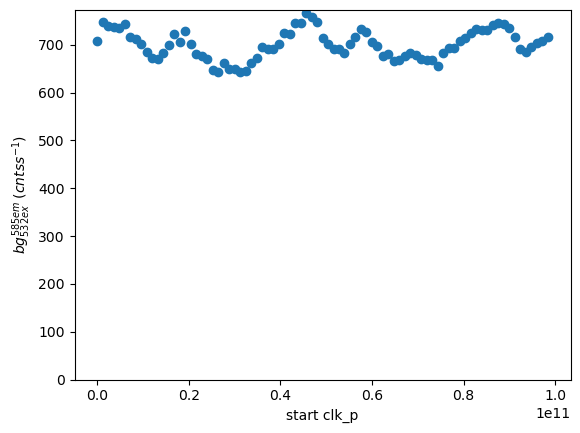

In [26]:
smf.plot.scatter(data, prd_start, bgDD)
plt.ylim(0)

(array([1, 2, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 3, 1,
        1, 2, 1, 0, 1, 1, 1, 1, 1, 2, 2, 2, 1, 0, 0, 0, 1, 4, 2, 0, 2, 0,
        1, 1, 0, 3, 2, 1, 2, 0, 2, 1, 0, 0, 1, 1, 2, 2, 1, 0, 0, 1, 1, 0,
        2, 0, 1, 0, 2, 1, 1, 1, 2, 0, 1, 1, 0, 1, 0, 2, 2, 1, 1, 1, 0, 0,
        0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1]),
 array([642.42530226, 643.66628724, 644.90727223, 646.14825721,
        647.38924219, 648.63022718, 649.87121216, 651.11219715,
        652.35318213, 653.59416711, 654.8351521 , 656.07613708,
        657.31712207, 658.55810705, 659.79909203, 661.04007702,
        662.281062  , 663.52204699, 664.76303197, 666.00401695,
        667.24500194, 668.48598692, 669.72697191, 670.96795689,
        672.20894187, 673.44992686, 674.69091184, 675.93189683,
        677.17288181, 678.41386679, 679.65485178, 680.89583676,
        682.13682175, 683.37780673, 684.61879171, 685.8597767 ,
        687.10076168, 688.34174667, 689.58273165, 690.82371663,
        692.064701

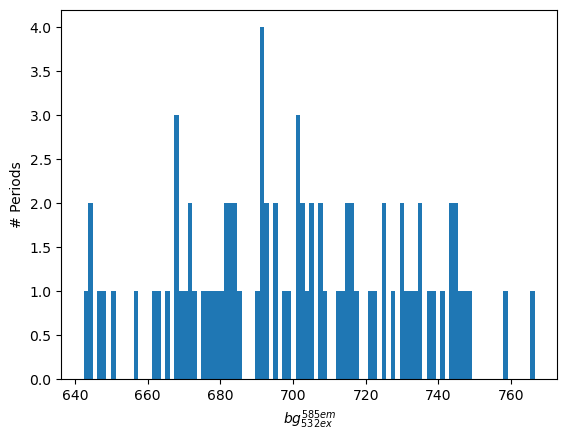

In [27]:
smf.plot.hist(data, bgDD)

#### Mapped Columns

Here is a good place to show how "mapped" columns work (when the "mapto" column is not a "-").

The "rangecounts" column of `smf.BG` tables allows you to "map" the background rates calculted from the `smf.Periods` 
on which the `smf.BG` param is based, to any time range, by any `smf.BasePhotonTable`.
The "destination" `smf.Param` is specified as the first key in key-tuple.

In [28]:
bgcnts = smf.Column(bg, 'rangecounts', 
                    (bursts, smf.PhSel('0ex0em'), 'istarttime', 'istoptime'))

We can see that this column can be combined with other matching burst columns, instead of with periods/bg columns:

In [29]:
data.get_frame(brst_dur, bgcnts)

,$duration$,"bg photons:(0ex0em,istarttime,istoptime)"
0,0.003652,2.581989
1,0.005721,4.044744
2,0.001281,0.905738
3,0.003913,2.766990
4,0.005311,3.754958
...,...,...
120075,0.001117,0.799911
120076,0.002436,1.745320
120077,0.001504,1.077294
120078,0.002722,1.950061


## `smf.Gate` and `smf.GateGroup` objects

Gates allow gating of data based on combinations of column values and paramters.

First we will introduce the easiest way to create `GateGroups`, show their function, and then explain more of the internals.

### `smf.gates.make_..._gate()` functions

smfBursts includes the following `make_..._gate()` functions:

- `smf.make_geq_gate(column:Column, mn:float)->GateGroup` Gate column by values greater than mn
- `smf.make_lt_gate(column:Column, mx:float)->GateGroup` Gate column by values less than or equal to mx
- `smf.make_ellipsoid_gate(colx:Column, coly:Column, cx:float=0, cy:float=0, dx:float=1.0, dy:float=1.0, theta:float=0.0, radians:bool=False)->GateGroup` values within specified ellipse, x and y set by colx and coly columns respectively.

These make specific `smf.GateGroup` objects with the specified parameters, based on the input columns.

In [30]:
nphD = smf.Column(bursts, 'nph_raw', (smf.PhSel('0ex'),))
nphAA = smf.Column(bursts, 'nph_raw', (smf.PhSel('1ex1em'),))
gtD50 = smf.make_geq_gate(nphD, 50)

These `smf.GateGroup` objects can then be applied to retreiving columns and frames by adding 
it as an argument to the `smf.datamodel.tables.DataSet.get_...` functions of `smf.datamodel.tables.DataSet` objects:

In [31]:
nD_ungated = data.get_column(nphD)
nD_gated = data.get_column(nphD, gate=gtD50)
print(f'Ungated size: {nD_ungated.size}, all larger than 50: {np.all(nD_ungated > 50)}')
print(f'Gated size: {nD_gated.size}, all larger than 50: {np.all(nD_gated > 50)}')

Ungated size: 120080, all larger than 50: False
Gated size: 4258, all larger than 50: False


In [32]:
dur_gated = data.get_column(brst_dur, gate=gtD50)
print(f'dur_gated size same as nD_gated: {dur_gated.size == nD_gated.size}')

dur_gated size same as nD_gated: True


Including the `smf.datamodel.tables.DataSet.get_frame()` method:

(0.0, 313.95)

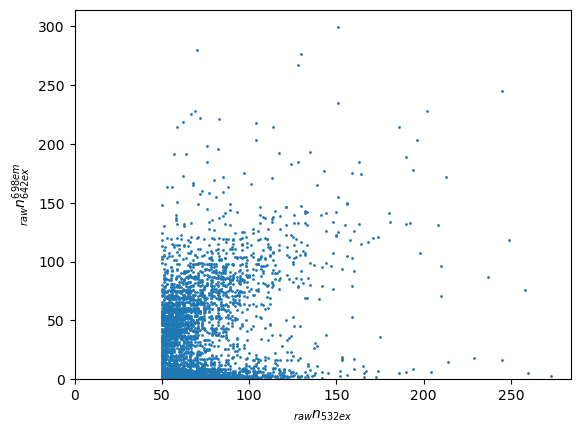

In [33]:
fr = data.get_frame(nphD, nphAA, gate=gtD50)
fr.plot.scatter(x=0, y=1, s=1.0)
plt.xlim(0)
plt.ylim(0)

And the same applied to plotting functions:

(0.0, 313.95)

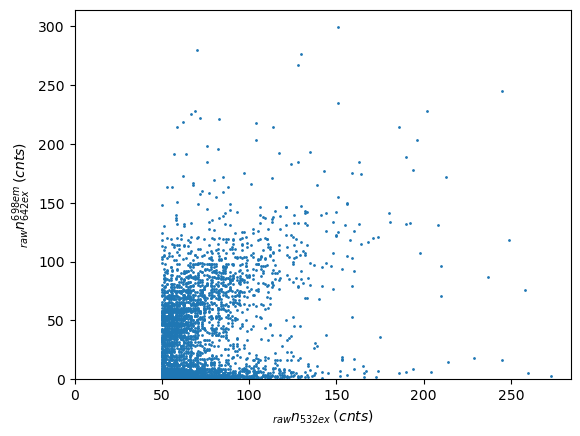

In [34]:
smf.plot.scatter(data, nphD, nphAA, gate=gtD50, include_unit=True, s=1.0)
plt.xlim(0)
plt.ylim(0)

### `smf.GateGroup` logical operations

`smf.GateGroup` s can be combined with essentially any logical operation.

So `gateC = gateA & gateB` will result in `gateC` being a gate that only includes rows that satify both conditions of `gateA` and `gateB`.

And `gateD = gateA | gateB` will resutl in `gateD` being a gate that includes rows that satify the condition of `gateA`, `gateB`, or both.

In [35]:
gtAA20 = smf.make_geq_gate(nphAA, 20)

gtD50aAA20 = gtD50 & gtAA20
gtD50oAA20 = gtD50 | gtAA20

(0.0, 312.95)

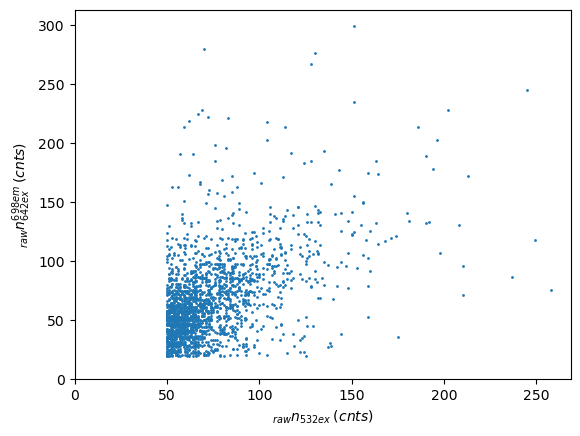

In [36]:
smf.plot.scatter(data, nphD, nphAA, gate=gtD50aAA20, s=1.0)
plt.xlim(0)
plt.ylim(0)

(0.0, 313.95)

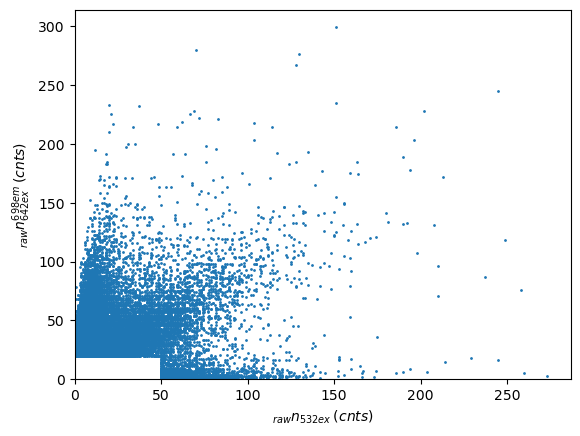

In [37]:
smf.plot.scatter(data, nphD, nphAA, gate=gtD50oAA20, s=1.0)
plt.xlim(0)
plt.ylim(0)

### `smf.Gate` and `smf.GateGroup` objects

The `smf.make_..._gate` functions return `GateGroup` objects, which are always used in gating tables.

Internally a `smf.GateGroup` has 2 properties:

1. truthtable: n-d boolean array, all dimensions of size 2
2. gates : tuple of `Gate` length is same as number of dimentions of truthtable

`smf.make_gt_gate()` produces a `smf.GateGroup` with a single `smf.Gate` in gates.
Performing the `&` or `|` operations result in an output `smf.GateGroup` with a
2D `smf.GateGroup.truthtable`, and containing 2 `smf.Gate` objects in its `smf.GateGroup.gates` attribute.

> **Note**
>
> For certain types of gates, smfBursts can detect if removing a `smf.Gate`
> will not change the result, and will therefore remove that gate, and adjust the truthtable accordingly.

#### Directly creating `smf.Gate` objects

When more complicated gates are required, especially ones that depend on more columns, `smf.Gate` objects
can be created directly, and `smf.GateGroup` created from the `smf.Gate` objects and `smf.GateGroup.truthtable` boolean arrays.

The `smf.Gate` object has 3 arguments:

1. gatedef : a `smf.GateDef` object, which is a wrapper around a gating function (returns boolean array), which specifies the necessary columns and parameters
2. columns : a tuple of `smf.Column` objects, specifying the columns on which the gating function should operate
3. params : a dictionary of additional arguments for the gatedef function.

Below is the "internal" call equivalent to `smf.make_geq_gate(nphD, 50.0)`

In [38]:
geq_50 = smf.Gate(smf.gates.LIN_GEQ_gate, (nphD,), 
                  {'vec':np.array([1.0]), 'm':50.0})

#### Creating `smf.GateGroup` objects

The syntax for creating a `smf.GateGroup` is `smf.GateGroup(gatedef, *gates)`
In other words, instead of packing the `Gate` objects into a tuple, for every `Gate` is specified as an addition argument.

We can now create the `smf.GateGroup` that `smf.make_geq_gate(nphD, 50.0)` is equivalent to:

In [39]:
gtD50 = smf.GateGroup(np.array([False, True]), geq_50)

An "inverted" `smf.GateGroup` can be created by inverting the truthtable:

In [40]:
lteD50 = smf.GateGroup(np.array([True, False]), geq_50)

##### `smf.gates.LIN_GT_gate` and `smf.gates.LIN_GEQ_gate` gate defs

`smf.datamodel.tables.GateDef` objects have a role in `smf.Gate` objects similar to the role of `smf.datamodel.tables.Table` types have in `smf.Param` objects.
Although it should be emphasized that it is *instances* of `smf.datamodel.tables.GateDef` that are used in `smf.Gate` objects, not the *type*.

`smf.gates.LIN_GT_gate` and `smf.gates.LIN_GEQ_gate` specify that:
1. Can accept any number of columns
2. params must contain keys`"vec"` and `"m"`
3. `"vec"` must be an array of the same length as the number of columns
4. `"m"` is a scallar

The gate function of `v.gates.LIN_GT_gate` (for a single row) is $vec \cdot cols > m$ where cols is the vector (per row) made up of each column.
For `smf.gates.LIN_GEQ_gate`, simply replace $>$ with $\ge$

So you can understand now that this is a "linear" where vec defines the vector normal to the n-plane above which the gate is true.

In [41]:
lin_gate = smf.Gate(smf.gates.LIN_GT_gate, (nphD, nphAA), 
                    {'vec':np.array([2.0,1.0]), 'm':100})
lin_gg = smf.GateGroup(np.array([False, True]), lin_gate)

(0.0, 313.95)

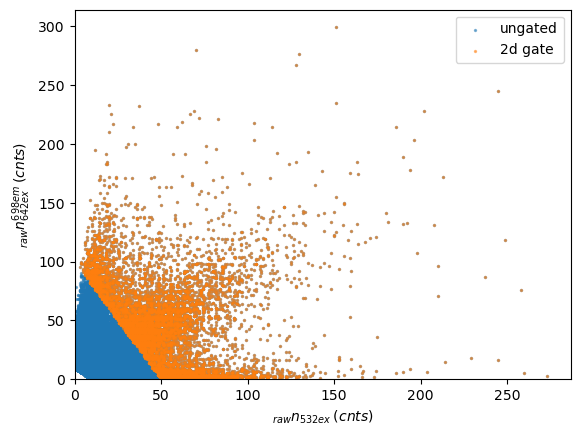

In [42]:
smf.plot.scatter(data, nphD, nphAA, label='ungated', s=2.0, alpha=0.5)
smf.plot.scatter(data, nphD, nphAA, gate=lin_gg, 
                 label='2d gate', s=2.0, alpha=0.5)

plt.legend()
plt.xlim(0)
plt.ylim(0)

(0.0, 313.95)

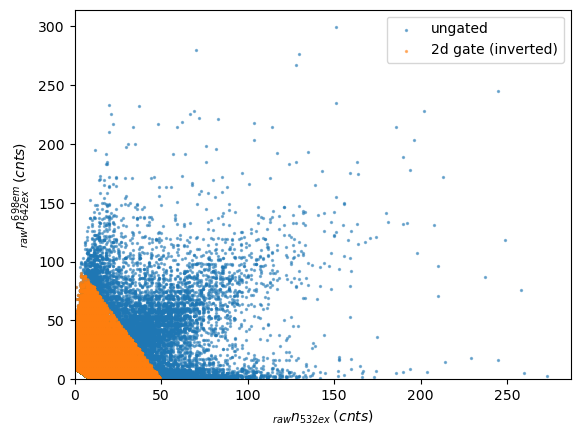

In [43]:
ilin_gg = smf.GateGroup(np.array([True, False]), lin_gate)
smf.plot.scatter(data, nphD, nphAA, label='ungated', s=2.0, alpha=0.5)
smf.plot.scatter(data, nphD, nphAA, gate=ilin_gg, 
                 label='2d gate (inverted)', s=2.0, alpha=0.5)

plt.legend()
plt.xlim(0)
plt.ylim(0)

### All and none `smf.GateGroup` objects

It is also possible to designate a `smf.GateGroup` that removes nothing, and one that removes everything.

These are so-called all and none gates, they contain a 0 size tuple for the `smf.Gategroup.gates` attribute, 
and a 0d 1 size array for the `smf.GateGroup.truthtable`.
"all" gates have a `True` value in this array, and none gates a `False`

All and none gates exist in 2 forms. The first form is the "generic" form, and can be applied to any Param/Column.
The second is a `smf.Param` specific form, which can only be applied to `smf.Param` and `smf.Column` objects 
based on a specific `smf.datamodel.tables.BaseTable` type `smf.Param`.

In [44]:
all_bursts = smf.GateGroup(np.array(True), param=bursts)
data.get_column(nphD, gate=all_bursts).size, data.get_column(nphD).size

(120080, 120080)

In [45]:
none_bursts = smf.GateGroup(np.array(False), param=bursts)
data.get_column(nphD, gate=none_bursts).size

0

The "generic" *all* and *none* gates are supplied as constants in smfBursts as `smf.GG_all` and `smf.GG_none`.
But you could also create them as `smf.GateGroup(np.array(True))` and `smf.GateGroup(np.array(False))`.

Regardless, you can see that they will work as gates on any `Column`

In [46]:
data.get_column(nphD, gate=smf.GG_all).size, data.get_column(nphD).size

(120080, 120080)

In [47]:
data.get_column(nphD, gate=smf.GG_none).size

0

## `smf.Param` and `smf.Column` with `smf.GateGroup` objects included

So far, the Column and Param objects represent the entirety of the data.
However, they can include gates, and so when used with the `get_...` methods, will return gated values.

There are 2 main ways do this:
1. Specify at creation
2. Using the `smf.Param.regate()`/`smf.Column.regate()` methods

### Creating `smf.Param` with a `smf.GateGroup`

When creating a `smf.Param` object, you can supply the additional argument of `gategroup`, which must be a `smf.GateGroup`.

Columns created from that `smf.Param` will share the same gate. 
Retreiving such a column returns an *identical* array as retreiving a column while specifying a gate.

#### Creating `smf.Param` and `smf.Column` objects with gates:

In [48]:
# create Param with gate
bursts_gated = smf.Param(smf.Bursts, bursts.params, bursts.parents, gtD50)
nphD_from_gated_param = smf.Column(bursts_gated, 'nph_raw', (smf.PhSel('0ex'),)) # column from gated param

print(f'from gated same as get_column with gate:{np.all(data.get_column(nphD_from_gated_param) == data.get_column(nphD, gtD50))}')

from gated same as get_column with gate:True


A gategroup argument can alse be added to a `smf.Column`, and again, the arrays are *identical*:

In [49]:
# create Column from ungated param and add gategroup
nphD_with_gategroup = smf.Column(bursts, 'nph_raw', (smf.PhSel('0ex'),), 
                                 gategroup=gtD50)

print(f'with gategroup same as get_column with gate:{np.all(data.get_column(nphD_with_gategroup) == data.get_column(nphD, gtD50))}')

with gategroup same as get_column with gate:True


Note that if the `smf.Param` used to create a column already has a gate, the gategroup of the
`smf.Param` is combined using the `&` operation with whatever gate is specified for the gategroup:

In [50]:
nphD_bcgategroup = smf.Column(bursts_gated, 'nph_raw', (smf.PhSel('0ex'), ), 
                              gategroup=gtAA20)

colnphD_bcgategroup = data.get_column(nphD_bcgategroup)
colnphD_post_gate = data.get_column(nphD, gtD50&gtAA20)
print(f'size of nphD_bcgategroup == size of nphD with gtD50&gtAA20: {colnphD_bcgategroup.size == colnphD_post_gate.size}')
print(f'arrays are identical: {np.all(colnphD_bcgategroup == colnphD_post_gate)}')

size of nphD_bcgategroup == size of nphD with gtD50&gtAA20: True
arrays are identical: True


#### `smf.datamodel.tables.DataSet.get_frame()` with `smf.Column` objects of different gates

If, when calling the `smf.datamodel.tables.DataSet.get_frame()` method, 
a gate is not specified, smfBursts takes the gate of each column, and performs an `&` operation between all columns.

In [51]:
nphD_gtD50 = smf.Column(bursts, 'nph_raw', (smf.PhSel('0ex'),), 
                        gategroup=gtD50)
nphAA_gtAA20 = smf.Column(bursts, 'nph_raw', (smf.PhSel('1ex1em'),), 
                          gategroup=gtAA20)
data.get_frame(nphD_gtD50, nphAA_gtAA20)

,$_{raw}n_{532ex}$,$_{raw}n_{642ex}^{698em}$
0,113,171
1,71,60
2,101,106
3,156,150
4,52,51
...,...,...
2075,53,59
2076,79,83
2077,66,95
2078,63,72


Note that the above gives the same result as if we specified both columns with `gategroup=gtD50&gtAA20`:

In [52]:
nphD_gtD50gtAA20 = smf.Column(bursts, 'nph_raw', (smf.PhSel('0ex'),), 
                              gategroup=gtD50&gtAA20)
nphAA_gtD50gtAA20 = smf.Column(bursts, 'nph_raw', (smf.PhSel('1ex1em'),), 
                               gategroup=gtD50&gtAA20)
data.get_frame(nphD_gtD50gtAA20, nphAA_gtD50gtAA20)

,$_{raw}n_{532ex}$,$_{raw}n_{642ex}^{698em}$
0,113,171
1,71,60
2,101,106
3,156,150
4,52,51
...,...,...
2075,53,59
2076,79,83
2077,66,95
2078,63,72


#### `smf.Param.regate()`/`smf.Column.regate()` method

Both `smf.Param` and `smf.Column` objects have a `smf.Param.regate()`/`smf.Column.regate()` methods that returns a `smf.Param` or `smf.Column`
with the specified gate:

In [53]:
bursts_rg = bursts.regate(gtD50)
nphD_brg = smf.Column(bursts_rg, 'nph_raw', (smf.PhSel('0ex'),))

nD_brg = data.get_column(nphD_brg)
print(f'regated has same size as get_column with gate: {nD_brg.size == nD_gated.size}')
print(f'regated is identical to get_column with gate: {np.all(nD_brg == nD_gated)}')

regated has same size as get_column with gate: True
regated is identical to get_column with gate: True


In [54]:
nphD_crg = nphD.regate(gtD50)

nD_crg = data.get_column(nphD_crg)
print(f'regated has same size as get_column with gate: {nD_crg.size == nD_gated.size}')
print(f'regated is identical to get_column with gate: {np.all(nD_crg == nD_gated)}')

regated has same size as get_column with gate: True
regated is identical to get_column with gate: True


### `base_gate`, `base_param` and `origin_param` attributes

`smf.Param`, `smf.Column`, and `smf.GateGroup` objects all have `base_gate`, `base_param` and `origin_param` properties.

These identify 2 things:
1. The rows of the instruction, either as a `smf.GateGroup` in the case of `base_gate`, or as a `smf.Param` with appropriately set gate in the case of `base_param`
2. The "origin" of the rows, ie the `smf.Param` object (always `smf.datamodel.tables.BaseTable`-based) object that defines the ungated definition of the rows.

If two `smf.Param` or `smf.Column` objects share the same `base_gate`/`base_param`, then they are "fully" compatible, 
i.e. the rows of one have a 1-to-1 coorespondence between the rows of the other.

If two instruction objects share the same `base_gate`/`base_param`, then they automatically share the same `origin_param`.

But is is possible for two instruction objects to share the same `origin_param`, but not the same `base_gate`/`base_param`.
In this case they two objects are only partially compatible, the rows of one will not correspond directly to the rows of the other.
However, a mapping between the two is possible, as demonstrated below:

Given the table with all its rows (origin), and the gates, you can see the indexes of GateA and GateB do not align to the same rows.

Origin | Gate A | Gate B
-------|--------|--------
0      |   -    |    0
1      |   0    |    -
2      |   1    |    -
3      |   2    |    1
4      |   -    |    2

But, we can "reconstruct" a mapping between them:

Gate A | matching index in GateB
-------|------------------------
   0   |   -
   1   |   -
   2   |   1


matching index inGate A |  GateB
------------------------|-------
|       -                |   0
|       2                |   1
|       -                |   2


Note that a `smf.Param` already based on `smf.datamodel.tables.BaseTable` will have a `base_param` that is itself, 
while a `smf.Param` based on a `smf.datamodel.tables.ChildTable` will have a `base_param` based on one of it's parents.

As a final note, while any `smf.Param`/`smf.Column` can be regated, the gategroup is always applied to the `base_param`.
So if you regate a `smf.Param` based on a `smf.datamodel.tables.BaseTable` you will change its `smf.Param.gategroup`,
however, if you regate a `smf.Param` based on a `smf.datamodel.tables.ChildTable`, the new gate is applied to the parent `smf.Param` that defines its `base_param`.
Therefore, `smf.Param` objects based on `smf.datamodel.ChildTable` never have a `smf.Param.gategroup` attribute.
*This means the most reliable way to determine the gate of an instruction object is to use the `base_gate` property.

`smf.Gate` objects also have a `base_gate`, `base_param` and `origin_param`.
The meaning of `origin_param` is the same for all other instruction objects, 
however since `smf.Gate` objects do not have defined rows, the meaning of `base_gate` and `parent_gate`are slighly different.
The `base_gate` of a `smf.Gate` is the gate that defines its full truthtable,
while the `parent_gate` is the gate the parent gate of `base_gate`.

In [55]:
bg.base_param == periods # demonstrate how base_param is shared between params based on childtable and basetable

True

#### How `origin_param` is used in `smf.Gate` and `smf.GateGroup` objects

The first place where the `origin_param` and `base_param` attributes become important is in creating `Gate` objects.

All `smf.Column` objects in a given `smf.Gate` must share the same `origin_param`.
An error is raised otherwise. This prevents errors when computing gates.

Further, the constructor for a `Gate` automatically removes any unecessary gates from `smf.Column` objects.
For all but non-atomic columns (which will be covered later), this means that regardless of the
gate of the `smf.Column` object(s) given when specifying a `smf.Gate`, they will be converted to non-gates (all gate) columns.

In [56]:
nphDD = smf.Column(bursts, 'nph_raw', (smf.PhSel('0ex0em'),), gategroup=gtD50)
nphAA = smf.Column(bursts, 'nph_raw', (smf.PhSel('1ex1em'),))
prstart = smf.Column(periods, 'start')
prstop = smf.Column(periods, 'stop')


colA, colB = (nphDD, prstart), (nphAA, prstop)
for ca in colA:
    for cb in colB:
        print(f'ca.origin_param == cb.origin_param : {ca.origin_param == cb.origin_param}', end='')
        try:
            test_gate = smf.Gate(smf.gates.LIN_GT_gate, (ca, cb), 
                                 {'m':100.0, 'vec':np.ones(2)/np.sqrt(2)})
            print(" can be combined in a gate")
        except Exception as e:
            print (f" cannot be combined in a gate, {e}")

ca.origin_param == cb.origin_param : True can be combined in a gate
ca.origin_param == cb.origin_param : False cannot be combined in a gate, columns must share origin_param
ca.origin_param == cb.origin_param : False cannot be combined in a gate, columns must share origin_param
ca.origin_param == cb.origin_param : True can be combined in a gate


## Offset and fill

So far 2 columns have been mentioned that have an offset other than 0.

Remember, this means that the number of rows in these columns are different from that of all the others.
But the difference is always consistent.
If a table has $n$ rows, then the number of rows in "periods" is always $n+1$ and in "sep" is always $n-1$
(they have offsets of 1 and -1 respectively).

This can create issues when retriving columns for data tables, and when making gates, where it is needed
for there to be $n$ rows.

To address such cases, when creating a `smf.Column` object for a column of one of these types, you can also specify the `smf.Column.offset` parameter.
This tells smfBursts how to align the column to all other columns.

It works by taking the column, an shifting it by the `smf.Column.offset` value.

### Positive column type offsets

For column types with a positive offset, if `col` is the starting column array, then: `offset_col = col[offset:col.size+offset]`
The size of the offset of a `smf.Column` can never exceed the absolute value of the column type's offset.

We can see this with the periods column type, specifying offset results in a column of size 1 less than not specifying:

In [57]:
prd = smf.Column(periods, 'periods')
prd_offset0 = smf.Column(periods, 'periods', offset=0)
p0 = data.get_column(prd_offset0)
p0.size, data.get_column(prd).size

(83, 84)

And, if we compare two columns otherwise identical, but with different offsets, we can slice them with opposite offsets, and find they are all equal:

In [58]:
prd_offset1 = smf.Column(periods, 'periods', offset=1)
p1 = data.get_column(prd_offset1)

np.all(p0[1:-1] == p1[0:-2])

np.True_

Also, as a point of interest, for the `Periods` param type, 
the "periods" column with an offset of 0 is the same as the "start" column.
and "periods" with an offset of 1 is the same as the "stop" column.

### Negative column type offsets

If the column type's offset is negative, this situation is only slightly more complicated.
The short version is that a fill value is also specified.

With negative column type offsets, the base column has too few values.
So some rows will have to have undefined values.
So a "fill" value must be specified to place in rows for which the column is undefined.

To understand this with indexing, if `col` is the column array with no offset, the output is created
by taking `offset_col` of size `n` of all "fill" values, and then setting `offset_col[offset:n+offset] = col`.
So you have fill values from 0 to the offset, and filling out whatever rows left after filling the remaining rows.

This is done by specifying a `fill` arguments when creating the `Column` object.

In the example below, not that the size of the column with an offset specified is 1 larger than the value without.

In [59]:
sep = smf.Column(bursts, 'sep', ('istarttime', 'istoptime'))
sp = data.get_column(sep)

sep0 = smf.Column(bursts, 'sep', ('istarttime', 'istoptime'), 
                  offset=0, fill=-np.inf)
sp0 = data.get_column(sep0)

sp.size, sp0.size

(120079, 120080)

and see how the value of -inf is included at the end, since the offset specified was 0, 
no nans are placed at the beginning, and a single -inf is placed at the end

In [60]:
sp0[-10:]

array([0.06683005, 0.1352586 , 0.00172625, 0.0020209 , 0.00149325,
       0.08264395, 0.01579365, 0.0012355 , 0.10718155,       -inf])

and now for an offset of 1, the -inf goes at the beginning instead

In [61]:
sep1 = smf.Column(bursts, 'sep', ('istarttime', 'istoptime'), 
                  offset=1, fill=-np.inf)
sp1 = data.get_column(sep1)
sp1[:10]

array([      -inf, 0.0464336 , 0.0039598 , 0.00857145, 0.03583605,
       0.10792215, 0.09242495, 0.04267995, 0.01015025, 0.00519655])

and finally, we can make the value comparison of all "middle values"

In [62]:
np.all(sp0[:-1] == sp1[1:])

np.True_

> **Note**
>
> Most negative offset columns have a default offset specified.
> These are chosen to be some value that is easily identifiable and rarely, if ever a value for a "real" row in the column.
>
> For floating point columns, this is typically nan, for integer, it is typically 0
> 
> This is the case with "sep".
> If a "sep" column is created with an offset, without specifying a fill value, a fill value of nan will be automatically set.

In [63]:
sep1_defaultfill = smf.Column(bursts, 'sep', ('istarttime', 'istoptime'), 
                              offset=1)

data.get_column(sep1_defaultfill)[:10]

array([       nan, 0.0464336 , 0.0039598 , 0.00857145, 0.03583605,
       0.10792215, 0.09242495, 0.04267995, 0.01015025, 0.00519655])

## Non-atomic columns

Now for the most nuanced type of column, non-atomic columns.
These columns have values that change depending on the gate that is applied.

> **Note**
> 
> These columns are usually the result of computations that involve comparing adjacent datapoints.
> Thus, removing points results in new "adjacent" points for the remaining data points.
> This also means that these columns often have a negative offset.

However, there will be cases where you will want to compute the values with one gate, but filter them according to another gate.
So non-atomic columns have 
1. Determiner gate: the gate that determines the values of the rows
2. Filter gate: the gate that determines which rows are returned

For non-atomic columns, the determiner gate specified in the param attribute, and the filter gate is set by the gategroup argument.
If no gategroup is set, it is automatically set to the same as the determiner gate.

### Determiner gates

Below, `sep_nogate` is created with a `Param` that has no gate applied, while `sep_gate` with a `smf.Param` that has had a gate applied.

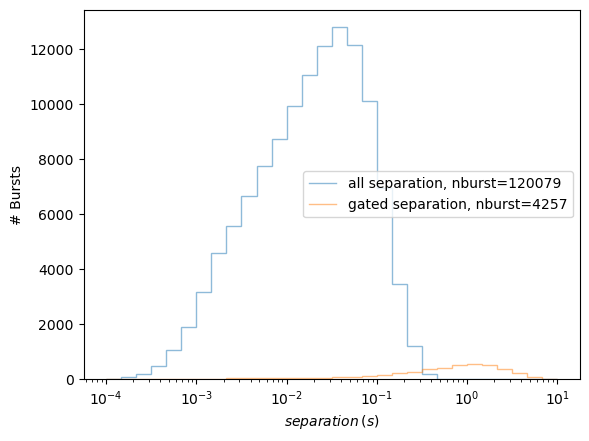

In [64]:
sep_nogate = smf.Column(bursts, 'sep', ('istarttime', 'istoptime'))
sng = data.get_column(sep_nogate)

sep_gate = smf.Column(bursts.regate(gtD50), 'sep', ('istarttime', 'istoptime'))
sg = data.get_column(sep_gate)

bins = np.logspace(-4, 1, 31)

smf.plot.hist_stair(data, sep_nogate, alpha=0.5, bins=bins, 
                    label=f'all separation, nburst={sng.size}')
smf.plot.hist_stair(data, sep_gate, alpha=0.5, bins=bins, 
                    label=f'gated separation, nburst={sg.size}', 
                    include_unit=True)
plt.xscale('log')
plt.legend()

In [65]:
sep_gate.gategroup == sep_gate.param.gategroup

True

You can see from the histogram of the values that
1. `sep_nogate` has many more rows, since the determiner gate of `sep_gate` removes many rows
2. The values of `sep_gate` are larger (by mean, median or mode) than those of `sep_nogate`,
   since removing rows means that there is greater time delta between remaining rows.

### Filter gates

Applying filter gates to non-atomic columns, as mentioned is done through the gategroup argument to `smf.Column`.

> **Note**
> In the below example, an offset is specified as well, since "sep" is also a column with a non-zero offset.
> When non-atomic columns have an offset and a filter gate not equal to the determiner gate, they must have an offset.
> Otherwise the filter gate cannot be alligned to the determiner gate rows.

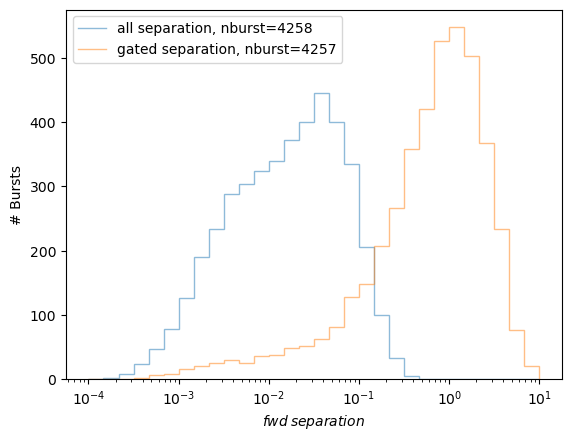

In [66]:
sep_nogatef = smf.Column(bursts, 'sep', ('istarttime', 'istoptime'), 
                         gategroup=gtD50, offset=0)
sngf = data.get_column(sep_nogatef)

sep_gatef = smf.Column(bursts.regate(gtD50), 'sep', ('istarttime', 'istoptime'), 
                       offset=0)
sg = data.get_column(sep_gate)

bins = np.logspace(-4, 1, 31)

smf.plot.hist_stair(data, sep_nogatef, alpha=0.5, bins=bins, 
                    label=f'all separation, nburst={sngf.size}')
smf.plot.hist_stair(data, sep_gatef, alpha=0.5, bins=bins, 
                    label=f'gated separation, nburst={sg.size}')
plt.xscale('log')
plt.legend()

Now you can see that the number of rows is the same between both columns, but the overall shape of the distributions
is overall the same as before, with the column created from an ungated `smf.Param` having much smaller values.

### Non-Atomic columns with filter gates larger than determiner gate

In the above example, the filter gate applied to the `sep_nogatef` column was "within"
the determiner gate of the `smf.Param` so all values- ie no row was included in the filter gate 
that was a not included in the determiner gate.

But it is possible to use any gate valid for the entire ungated table param as a filter gate.
In this case, the filter and determiner gates are intersecting.
So, as with negative offset columns, a fill value is specified, (defaults often included)
for all rows in the filter gate, but not in the determiner gate.

In [67]:
sep_gate_fi = smf.Column(bursts.regate(gtD50), 'sep', ('istarttime', 'istoptime'), 
                         offset=0, fill=np.inf, gategroup=gtAA20)
data.get_column(sep_gate_fi)[:20]

array([       inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf, 0.55475415,        inf,        inf,        inf])

#### `smf.Gate` based on non-atomic `smf.Column`

Non-atomic gates include an additional `smf.Gate.expand` attribute.

This is because `smf.Gate` objects must provide instructions for how to create a boolean value for *every* row in the *origin_param*.
But since a non-atomic column has no values outside of the determiner gate, the value for rows not in that gate must be specified separately.
This is done with the `smf.Gate.expand` attribute.

The main reason for an `expand=True` attribute in a `smf.Gate` is because the `smf.GateGroup` object *inverts* the gate.

In order to reduce the number of `smf.gates.GateDef` objects and thus simplify internal comparison,
smfBursts only implements $\gt$ and $\ge$ `smf.gates.GateDef` and relies on inverted truthtables to create $\lt$ and $\le$ gates.

Let's demonstrate a simple example below.

The `sep_gate` column is the separtion bewteen the current and previous datapoint for datapoints filtered with the `gtD50` `smf.GateGroup`.

Let's further filter this for bursts with a value greater that `0.1`

The `smf.gates.LIN_GT_gate` is perfect for this, with `m=0.1, vec=np.array([1.0])` as params.
Since it is already a $\gt$ gate, when we crate the `smf.GateGroup`, 
we should use the "standard" truthtable `[False, True]`, and so for the `smf.Gate`, `expand=False`

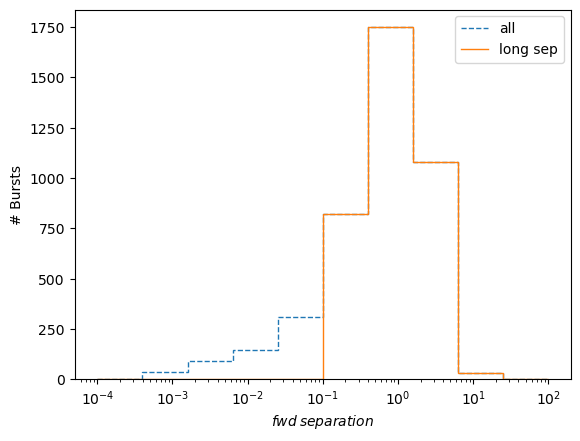

In [68]:
logbins = np.logspace(-4,2, 11)
sepGE0_1 = smf.Gate(smf.gates.LIN_GT_gate, sep_gatef, 
                    {'m':0.1, 'vec':np.array([1.0])})
gsepGE0_1 = smf.GateGroup(np.array([False, True]), sepGE0_1)
csepGE0_1 = sep_gatef.regate(gsepGE0_1)
smf.plot.hist_stair(data, sep_gatef, bins=logbins, label='all', ls='--')
smf.plot.hist_stair(data, csepGE0_1, bins=logbins, label='long sep')
plt.xscale('log')
plt.legend()

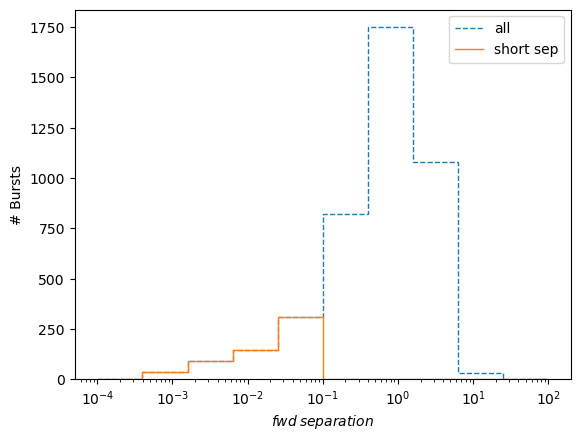

In [69]:
sepGE0_1i = smf.Gate(smf.gates.LIN_GT_gate, sep_gatef, 
                     {'m':0.1, 'vec':np.array([1.0])}, expand=True)

gsepLEQ0_1 = smf.GateGroup(np.array([True, False]), sepGE0_1i)
csepLEQ0_1 = sep_gatef.regate(gsepLEQ0_1)

smf.plot.hist_stair(data, sep_gatef, bins=logbins, label='all', ls='--')
smf.plot.hist_stair(data, csepLEQ0_1, bins=logbins, label='short sep')
plt.xscale('log')
plt.legend()

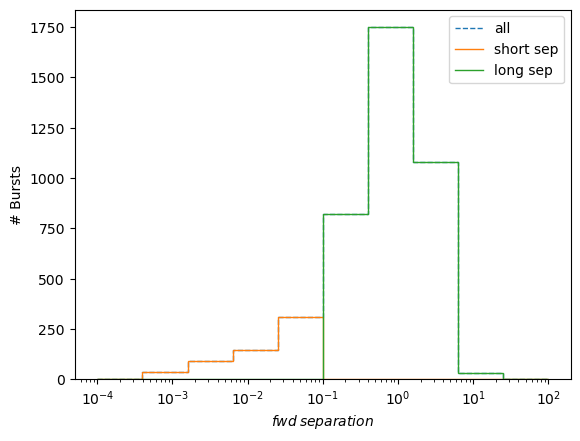

In [70]:
smf.plot.hist_stair(data, sep_gatef, bins=logbins, label='all', ls='--')
smf.plot.hist_stair(data, csepLEQ0_1, bins=logbins, label='short sep')
smf.plot.hist_stair(data, csepGE0_1, bins=logbins, label='long sep')
plt.xscale('log')
plt.legend()

#### `parent_gate` and `parent_param` properties

In addition to the `base_gate`/`base_param` properties, all instruction objects also have `parent_gate` and `parent_param` properties.
If all columns used are atomic, then these properties simply give the "all" gate and `origin_param` respectively.

However, when non-atomic columns or gates are involved, it is useful to know not just the output rows of the filter gate,
but also the rows used in computation (and potentially which rows in the filter are not in the computation).
This is achieved through the `parent_gate`/`parent_param` objects.
The relation between `parent_gate` and `parent_param` is the same as that for `base_gate` and `base_param`.

So for a non-atomic `smf.Column` object, the `smf.Column.parent_param` attribute is its *determiner* gate.
(the `smf.Column.base_param` for a non-atomic column is its *filter* gate)

Let's recrate a non-atomic `smf.Column` with different *determiner* and *filter* gates and see how this works:

In [71]:
sep_gatef_AA20 = smf.Column(bursts.regate(gtD50), 'sep', ('istarttime', 'istoptime'), 
                            offset=0, gategroup=gtAA20)

print(f"determiner gate is the parent_gate: {sep_gatef_AA20.parent_gate==gtD50}")
print(f"determiner gate is the base_gate: {sep_gatef_AA20.base_gate==gtD50}")
print(f"filter gate is the parent_gate: {sep_gatef_AA20.parent_gate==gtAA20}")
print(f"filter gate is the base_gate: {sep_gatef_AA20.base_gate==gtAA20}")

determiner gate is the parent_gate: True
determiner gate is the base_gate: False
filter gate is the parent_gate: False
filter gate is the base_gate: True


When a `smf.Gate` uses a non-atomic `smf.Column`, its `parent_gate` is the `parent_gate` of that column.
Further, when creating a `smf.Gate`, the *filter* gate is always ignored.
This means it will not raise an error, but it will be the same as if you created the `smf.Gate` after performing `smf.Column.degate()` on the `smf.Column`.

> **Note**
>
> In the case of multiple non-atomic columns, the `smf.Gate.parent_gate` is the intersect (`&`) of all `smf.Column.parent_gate`.
> Since atomic columns always have an "all" `parent_gate`, they have no impact on the final `smf.Gate.parent_param`.

In [72]:
gate_pdict = {'m':0.01, 'vec':np.array([1.0])} # so both gates get same parameters
lsep_gatef = smf.Gate(smf.gates.LIN_GEQ_gate, (sep_gatef_AA20), gate_pdict)
lsep_gate = smf.Gate(smf.gates.LIN_GEQ_gate, (sep_gatef_AA20.degate()), gate_pdict)

print(f"parent_gate of Gate from non-atomic column is the column's parent_gate: {lsep_gatef.parent_gate==sep_gatef_AA20.parent_gate}")
print(f"gate from degated non-atomic column is same as from gated: {lsep_gatef==lsep_gate}")

parent_gate of Gate from non-atomic column is the column's parent_gate: True
gate from degated non-atomic column is same as from gated: True


`smf.GateGroup` objects operate on the same principle.
Their `smf.GateGroup.parent_gate` is always the intersect of all `smf.Gate.parent_gate` of their underlying `smf.Gate` objects.

#### A final note on `parent_gate`

While `smf.GateGroup` and `smf.Gate` objects have `parent_gate`/`parent_param` properties, 
they are still defined (because of the `smf.Gate.expand` attribute) for all rows of their `origin_param`.

This means that the primary place where `parent_gate` is used is in the `smf.Column` objects.
`smf.Param` objects also have a `smf.Param.parent_gate` property, which is the same as the `parent_gate` of its gate.
Again, this is rarely used.

To make a final observation: `smf.Column.degate()` returns an object where the `smf.Column.base_gate` is the same as `smf.Column.parent_gate`.
This is true for both atomic and non-atomic columns, since for atomic columns the `smf.Column.parent_gate` is by definition an "all" gate.

In [73]:
sep_gate = sep_gatef.degate()
nphD_regatedegate = nphD.regate(gtD50).degate()
sep_gate.parent_gate == sep_gate.base_gate, nphD_regatedegate.parent_gate == nphD_regatedegate.base_gate

(True, True)

### MappedGates

The `smf.MappedGate` is a specialized type of gate, which functions equivalently to a `smf.Gate` inside a `smf.GateGroup` object.

It allows for re-ordering (mapping) of values within a gate.
This is useful for instance if you want to create a gate where the true/false value of a given row is determined by the gate of the previous/next row in said table.
This was primarily motivated by [RASP](https://doi.org/10.1039/C0CP01911A), where the change between pairs of closely spaced in time bursts is compared.

A `smf.MappedGate` has three components:

Name          | Description
--------------|--------------------------------------------------------------------------------------------
`gatedef`     | A `smf.tables.MappedGateDef` object defining the mapping function uses.
`param`       | Arguments to the `gatedef` function
`source_gate` | The rows of the Table handed to `gatedef` function, serves as the `base_gate` of the gate.
`mask_gate`   | The mask values handed to `gatedef` handed to `gatedef` function.
`expand`      | Value with which to fill rows ouside of `source_gate`.

The only predefined `smf.datamodel.tables.MappedGateDef` is `smf.gates.SHIFT_mapgate`.
The remapping function shifts the true/false values by offset, 
filling the first (if offset is posive) or last (if offset is negative) offset columns with fill:

|params                |   | | | | | | |
|----------------------|---|---|---|---|---|---|---|
| offset = 1 fill = x  | x | F | T | T | T | F | F |
| baseline             | F | T | T | T | F | F | T |
| offset = -1 fill = x | T | T | T | F | F | T | x |

In [74]:
# create offset 1 "reverse" sep column so a reverse sep gate can be made
sep_gatef = smf.Column(bursts.regate(gtD50), 'sep', offset=0)
sep_gater = smf.Column(bursts.regate(gtD50), 'sep', offset=1)

sepGE0_1i_f = smf.Gate(smf.gates.LIN_GT_gate, sep_gatef, 
                       {'m':0.1, 'vec':np.array([1.0])}, expand=True)
sepGE0_1i_r = smf.Gate(smf.gates.LIN_GT_gate, sep_gater, 
                       {'m':0.1, 'vec':np.array([1.0])}, expand=True)
gsepLEQ0_1_f = smf.GateGroup(np.array([True, False]), sepGE0_1i_f)
gsepLEQ0_1_r = smf.GateGroup(np.array([True, False]), sepGE0_1i_r)

# or gate so that we have all rows with sep either forward or back less than 0.1
gsepLEQ0_1_fr = gsepLEQ0_1_f | gsepLEQ0_1_r

Now that we have the gate for recurrent pairs, we can look at how pairs change.
Below we take the gate that is only True if the next burst is within 0.1 s, *AND* has a size if the 0ex channel greater than 100,
by making a shift gate with offset of 1, and mask gate of our pairs we can see how the previous magnitude affects the size of a recurrent burst.

(array([1, 4, 3, 5, 1, 1, 2, 4, 0, 0, 2, 4, 0, 3, 0, 1, 0, 2, 2, 1, 2, 2,
        4, 2, 0, 1, 0, 4, 0, 0, 2, 2, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 3, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]),
 array([ 50.  ,  50.88,  51.76,  52.64,  53.52,  54.4 ,  55.28,  56.16,
         57.04,  57.92,  58.8 ,  59.68,  60.56,  61.44,  62.32,  63.2 ,
         64.08,  64.96,  65.84,  66.72,  67.6 ,  68.48,  69.36,  70.24,
         71.12,  72.  ,  72.88,  73.76,  74.64,  75.52,  76.4 ,  77.28,
         78.16,  79.04,  79.92,  80.8 ,  81.68,  82.56,  83.44,  84.32,
         85.2 ,  86.08,  86.96,  87.84,  88.72,  89.6 ,  90.48,  91.36,
         92.24,  93.12,  94.  ,  94.88,  95.76,  96.64,  97.52,  98.4 ,
         99.28, 100.16, 101.04, 101.92, 102.8 , 103.68, 104.56, 105.44,
        106.32, 107.2 , 108.08, 108.96, 109.84, 110.72, 111.6 , 112.48,
        11

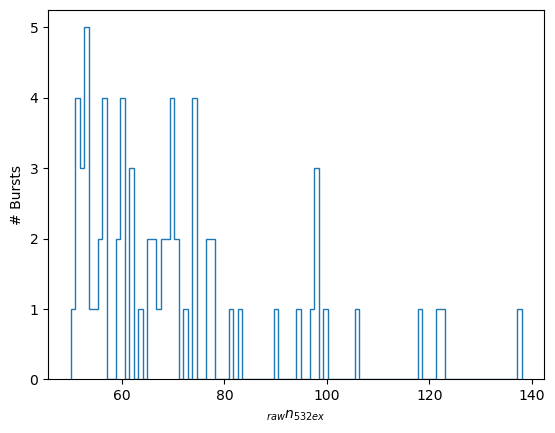

In [75]:
gD100 = smf.GateGroup.as_gategroup(smf.Gate(smf.gates.LIN_GEQ_gate, nphD, 
                                            {'m':100.0, 'vec':np.array([1.0])}))
gD100_sepLEQ0_1_f = gD100 & gsepLEQ0_1_f
mshift = smf.MappedGate(smf.gates.SHIFT_mapgate, {'offset':1, 'fill':False}, 
                        gsepLEQ0_1_fr, gD100_sepLEQ0_1_f)
g_mshift = smf.GateGroup(np.array([False, True]), mshift)

smf.plot.hist_stair(data, smf.Column(bursts, 'nph_raw', smf.PhSel('0ex')), 
                    gate=g_mshift)

Here's a diagram to explain the process

All bursts:

0.......1.2........3......4.5.6................7.....8.9...

Now filter by closely separated in the forward direction (`gsepLEQ0_1_f`):

X.......1.X........X......4.5.X................X.....8.X...

Now filter by closely separated in the reverse direction (`gsepLEQ0_1_r`):

X.......X.2........X......X.5.6................X.....X.9...

Then the OR gate gets only closely spaced bursts (recurrent pairs) (`gsepLEQ0_1_fr`):

X.......1.2........X......4.5.6................X.....8.9...


A shift gate with offset 1 with source gate of `gsepLEQ0_1_f` and mask gate `gsepLEQ0_1_f` would give:

|      |   |
|------|---|
Source:|X.......1.2........X......4.5.6................X.....8.9...
Mask  :|X.......1.X........X......4.5.X................X.....8.X...
Shift (show number of "source bursts") :|X.......X.1........X......X.4.5................X.....5.8...

By adding into the mask gate another condition, the remaining numbers can be filtered, and you can isolate population based on how neighboring bursts behave.

## Summary

| Name        | Purpose                                                                                                                 | Signature |
|-------------|-------------------------------------------------------------------------------------------------------------------------|---|
| `Param`     | Defines analysis constants such as thresholds and correction factors etc.                                               | `Param(tp:type, params:dict[str:Any], parents:dict[str:Param], gategroup:GateGroup=None, name:str=None, keys:list[str]=None)` |
| `Column`    | Selection of particular data value, like FRET efficiency, photon count etc.                                             | `Column(param:Param, col:str, keytup:tuple[Hashable,...], gategroup:GateGroup=None, offset:int=None, fill:Hashable=None, title:str=None, unit:str=None, index_title:str=None, index_unit:str=None, title_is_tex:bool=False)` |
| `Gate`      | Gate (aka filter or mask) defined by single gate function. *Note* rarely directly created, always wrapped in `GateGroup | `Gate(gatedef:GateDef, columns:tuple[Column,...], params:dict[str,Hashable], expand:bool=None, )` |
| `GateGroup` | Logical operation on a set of `Gate` gates. *Note* these are usually created with `make_..._gate functions              | `GateGroup(truthtable:np.ndarray[np.bool_], *gates:Gate, param:Param=None, title:str=None)`|

> **Note**
>
> With the exception of `smf.GateGroup`, all instructions have attributes the match the names of the arguments used to specify them.
> Further, these fully define the instructions.
> All additional information are implemented as properties.

### Data-like objects

#### `smf.datamodel.tables.DataSet` class

`DataSet` objects 
(usually subclassed, `DataSet` behaves somewhat like an abstract base class)
store the base unprocessed data that is to be analyzed with all other methods.

The important methods in `DataSet` are
1. `DataSet.get_table()`
2. `DataSet.get_column()`

`DataSet` stores a cache of all tables created from it with the `get_` methods.

#### `smf.datamodel.tables.Table` class

The abstract base class of any type that can be used in a `Param`.
This class implements the methods common to both `BaseTable` and `ChildTable`
like the index-like access of columns, getting colmndefs, adding columnts etc.


#### `smf.datamodel.tables.BaseTable` subclass

The abstract subclass of `Table` used to define `Param` that are base-params.
This class implements the necessary methods in a way to start a new table.


#### `smf.datamodel.tables.ChildTable` subclass

The abstract subclass of `Table` used to define `Param` that are child-params.
This class implements the necessary methods in a way 
such that it checks they are consistent with the base table.

### Instruction-like objects

#### `smf.Param` objects

`smf.Param`s give instructions for creating a table of values.
`smf.Param` objects are immutably defined by:
1. `smf.Param.tp` a `smf.datamodel.tables.Table` subclass, what type of table the param will create. Defines what parameters and parents need to be defined.
2. `smf.Param.params`: a dictionary of parameters. The thresholds and constants associated with the instructions.
3. `smf.Param.parents`: a dictionary of `smf.Param`, the tables on which the current table depends.
4. `smf.Param.gategroup`: a `smf.GateGroup`, defines which datapoints (rows) belong inside table.
   If not specified, assume `smf.GG_all`. Rarely accessed directly.
   Only applies to `smf.datamodel.tables.BaseTable` tp `smf.Param`.
   If present `smf.Param.gategroup.origin_param` must match `smf.Param.origin_param`

It has 2 mutable attributes: 
1. `smf.Param.name`: expected to be a string to identify the `smf.Param`. Expected to be used as a "nickname"
2. `smf.Param.flags`: a dictionary, used to suggest ways of processing/expectations

There are several important properties of `smf.Param` objects, which help define how it can be combined/used. 
`smf.Param` that share `smf.Param.base_gate`/`smf.Param.base_param` have the same rows, 
therefore columns from these can be directly compared (rows match). 
Note that these properties are present in all other instruction objects.

1. `smf.Param.base_param`: the `smf.Param` with a `smf.Param.tp` that is a `smf.datamodel.tables.BaseTable` that defines the rows of the table
2. `smf.Param.base_gate`: the `smf.GateGroup` of the `smf.Param.base_param`, the gate of the table.
   `smf.Param` that share `smf.Param.base_gate`/`smf.Param.base_param` have the same rows, therefore columns from these can be directly compared (rows match).
3. `smf.Param.parent_param`: the `smf.datamodel.tables.BaseTable` `smf.Param` with gate of the *parent gate* of the gategroup. This is rarely used.
4. `smf.Param.parent_gate`: The *parent gate* of the gategroup, the gate of the columns on which the gategroup is defined. This is rarely used.
5. `smf.Param.origin_param`: The `smf.Param` that defines the *ungated* rows.
   If two `smf.Param` share the same `smf.Param.origin_param`, then it is possible to align rows of one to another.

The mehods of `smf.Param` that return modified versions of `smf.Param` objects are:
1. `smf.Param.degate()`: takes no arguments, a verstion of the `smf.Param` object with no gate (ie "all" gate)
2. `smf.Param.regate(gate:smf.GateGroup)`: return a version of the `smf.Param` object with the gate `gate`

The property `smf.Param.description` returns a YAML-like description of the `smf.Param`. 
This is good for putting in a publication to share the data analysis parameters.

#### `smf.Column` objects

`smf.Column` object give instructions for retrieving a specific column from a table.
`smf.Column` objects are immutably defined by:
1. `smf.Column.source_param` the `smf.Param` of the table from which the column originates.
   Usually this contains the gate of the column.
   There are two exceptions:
   a) if the column is mapped to another table, or b) the column is non-atomic,
   if the column is not mapped,
   then the gate of `smf.Param.source_param` is used to define how the non-atomic column is calculated,
   if the column is both mapped and non-atomic,
   then the gate for computing the column comes from the first element of the `smf.Column.keytup`
2. `smf.Column.col` a string defining which column (or group of columns) should originate. These are some sort or datapoint parameter.
3. `smf.Column.keytup`: a `smf.Column.col` specific sequence (converted to tuple) of values.
   If column is mapped, the first element is the `smf.Param` defining the desitation table.
4. `smf.Column.gategroup`: a gategroup, only used with non-atomic columns. If present, defines the rows of the column.
   If present `smf.Param.gategroup.origin_param` must match `smf.Param.origin_param`
5. `smf.Column.offset`: int, non-negative. Only for columns with non-zero offset, the number of rows by which to offset values.
6. `smf.Column.fill`: defined by column dtype, for offset and non-atomic columns,
   value which is placed in rows for which the value is not defined,
   either due to offset size or non-atomic filter gate/determiner gate mismatch.

It has 5 mutable attributes:
1. `smf.Column.title`: a string giving a human readable title (for axes), may be a latex math formatted string (but should not include surounding \$ symbols)
2. `smf.Column.unit`: a string giving a human readable unit (for axes), like `smf.Column.title`, may be latex math formatted, not including \$ symbols, if `smf.Column.title` is latex, so should `smf.Column.unit`
3. `smf.Column.index_title`: a string giving a title for the column for use in csv files (should be alphanumeric, no commas)
4. `smf.Column.index_unit`: a string giveing a unit to append to the title of the column for use in csv files (should be alphanumeric, no commas)
5. `smf.Column.title_is_tex`: a bool, if `True` when formatting title with `smf.Column.name()`,
   will surround output with \$ symbols so matplotlib will read as latex math.

Because of mapped columns, `smf.Column` implements the following property:
- `smf.Column.param`: the `smf.Param` which defines the rows.
  If the column is mapped, this is the first element of `smf.Column.keytup`, otherwise it is the `smf.Column.source_param`.
  In the case of non-atomic columns, this is the `smf.Param` that defines how the values are calculated (its gate is used in computing the values)

The important properties of `smf.Column` objects common all instruction objects are:
1. `smf.Column.base_param`: The `smf.Param` with `smf.Param.tp` that is a `smf.datamodel.tables.BaseTable` that defines the rows that are present in the column. Note that for non-atomic columns, this is the output rows, not the gate used to compute the values. Also note that this matches `smf.Column.base_gate.base_param`.
2. `smf.Column.base_gate`: The `smf.GateGroup` that defines the rows of output. If non-atomic, this is the *filter* gate.
3. `smf.Column.parent_param`: The `smf.Param` that defines the rows. This is the `smf.Param` that has a gategroup of `smf.Column.parent_gate`
4. `smf.Column.parent_gate`: The gate used to define the values of the column. If atomic, this an "all" gate. If non-atomic, this is the gate used to compute the values.
5. `smf.Column.origin_param`: The `smf.Param` that defines the *ungated* rows.
   If two `smf.Column`s share the same `smf.Column.origin_param`, then it is possible to align rows of one to another.

The mehods of `smf.Column` that return modified versions of `smf.Column` objects are:
1. `smf.Column.degate()`: Takes no arguments, returns a `smf.Column` that contains all rows for which the column is defined.
   This means that `smf.Column.parent_gate` will be the same as `smf.Column.base_gate`.
   For atomic columns this will be an "all" gate, for non-atomic, this will mean the *filter* gate will be set to match the *determiner* gate.
   Note how this functions slightly differently than the nearly equivalent method of `smf.Param.degate()`,
   where, since a `smf.Param` cannot be thought of as atomic or non-atomic, the "all" gate is always returned,
   while here, for a `smf.Column`, it is switching to maximally defined gate.
   To ensure a column returns all possible rows, use `smf.Column.regate(smf.GG_all)`
2. `smf.Column.regate(gate:smf.GateGroup, fill=None)`: Return a column whose rows match the rows of `gate`, i.e. the `smf.Column.base_gate` will be `gate`.
   For atomic columns, this means regating the `smf.Column.param` (depending of if the column is mapped,
   either the first element of `smf.Column.keytup` or `smf.Column.source_param`), for non-atomic columns, the `smf.Column.gategroup` is set to `gate`.
   If the column has a negative offset or is non-atomic and the new gate is larger than the `smf.Column.parent_gate`,
   the `fill` value can be specified to also change it.
   If no `fill` is specified, but in moving from the old gate to the new, is should be, the column type's default will be automatically used.

The property `smf.Column.description` returns a YAML-like description of the `smf.Column`. 
This is good for putting in a publication to share the data analysis parameters.

There are also the following methods for getting other types of descriptions of the `smf.Column`:
1. `smf.Column.name(include_unit:bool=False)->str` Returns a string, name formated for an axis label
2. `smf.Column.index_name(include_unit:bool=False)->str`Returns a string, a name suitable for csv column title.

#### `smf.Gate` objects

These defines a "single" gate. They are always wrapped in `smf.GateGroup` objects for final computation.
`smf.Gate` objects have the following attributes:
1. `smf.Gate.gatedef`: a `smf.datamodel.tables.GateDef` *object* which defines the function used to compute the gate.
   Also determines size of `smf.Gate.columns` and contents of `smf.Gate.params` attributes
2. `smf.Gate.columns`: a tuple of column objects. The input columns to the `smf.Gate.gatedef` function. These are automaticaly `smf.Column.degate()` before attribute is set.
3. `smf.Gate.params`
4. `smf.Gate.expand` bool, only present when `smf.Gate.gatedef` is a non-atomic function,
   or one or more of the `smf.Column`s in `smf.Gate.columns` is non-atomic.
   The value to place in rows for which the gate is not defined (rows not in `smf.Gate.parent_gate`)

The important propeties of `smf.Gate` common to all instruction objects are:
1. `smf.Gate.base_param`: The `smf.Param` with `smf.Param.tp` that is a `smf.datamodel.tables.BaseTable`
   that defines the rows of the columns that are handed to `smf.Gate.gatedef.func`.
   This is identical to the `smf.Gate.parent_param`, and thus rarely used.
   All rows outside `smf.Gate.base_param` recieve the value specified in `smf.Gate.expand`.
2. `smf.Gate.base_gate`: The `smf.GateGroup` that defines the rows of the columns that are handed to `smf.Gate.gatedef.func`.
   This is identical to `smf.Gate.parent_gate` and thus rarely used.
   All rows outside `smf.Gate.base_gate` recieve the value specified in `smf.Gate.expand`.
3. `smf.Gate.parent_param`:
4. `smf.Gate.parent_gate`: The gate of the rows of columns handed to `smf.Gate.gatedef.func`,
   this is the intersect of the `smf.Column.parent_gate` of all `smf.Column` objects in `smf.Gate.columns`.
   When generating columns for handing to `smf.Gate.gatedef.func`,
   the equivalent of the following is called: `dataset.get_columns(col.regate(gate.parent_gate))`,
   where `dataset` is a `smf.datamodel.tables.DataSet` object,
   `col` is one of the `smf.Column` objects in `gate.columns`, and `gate` is the `smf.Gate` object in question.
   All rows outside `smf.Gate.parent_gate` recieve the value specified in `smf.Gate.expand`.
5. `smf.Gate.origin_param`: The `smf.Param` with `smf.Param.tp` that is a `smf.datamodel.tables.BaseTable` with an "all" gate,
   defining all possible rows for which the `smf.Gate` can be evaluated.
   Only `smf.Gate` objects with same `smf.Gate.origin_param` may be combined in `smf.GateGroup` objects.

#### `smf.GateGroup` objects

The `smf.GateGroup` object performs a logical operation on any number of `smf.Gate` objects.
On creation it compares the input `smf.Gates`, and if the opeartion is independent of an input gate, it is automatically removed.
This both reduces computation time later on, but also ensures if the same fundamental gate is defined in two ways, the created gate objects will be identical.

`smf.GateGroup` objects have 2 attributes:
1. `smf.GateGroup.truthtable` a N-d boolean array, all dimensions of size 2.
   Defines the truthtable of the logical operation being performed. indexing as follows,
   if a gate is `False`, the index along that dimension is 0,
   if `True`, then 1.
   Index in C-like order, ie for `smf.GateGroup.truthtable[smf.GateGroup.gates[0], smf.GateGroup.gates[1],...]`, indexed like C, and numpy index.
2. `smf.GateGroup.gates` a tuple of `smf.Gate` objects, length N
   (ie must match number of dimensions of `smf.GateGroup.truthtable`).
   All elements must share the same `smf.Gate.origin_param`
3. `smf.GateGroup.param`: a `smf.Param` with "all" gate, usually infered from `smf.GateGroup.gates`.
   If specifying a specific "all" or "none" gate, the `smf.Param` is specified here.
   If not specified and no `smf.GateGroup.gates` are specified (ie just `smf.GateGroup.truthtable` is specified as 0d array) and
   `smf.GateGroup.param` is not specified, creates an "all" or "none" generic `smf.GateGroup`
   (this is unnecessary, as these are already provided with `smf.GG_all` and `smf.GG_none`)

Note that when specifying a `smf.GateGroup`, the first argument is the `smf.GateGroup.truthtable`, 
and the following arguments (either `smf.Gate` or `smf.GateGroup`) are upacked into gates
that become the gates in the tuple `smf.GateGroup.gates`.

`smf.GateGroup` has 1 mutable attribute:
1. `smf.GateGroup.title` a string intended as a human readable title/name for the gate.

The important properties of `smf.GateGroup` objects common all instruction objects are:
1. `smf.GateGroup.base_param`: The `smf.Param` with `smf.Param.tp` that is a `smf.datamodel.tables.BaseTable` with the rows of the `smf.GateGroup`
2. `smf.GateGroup.base_gate`: This is always the "self" (the `smf.GateGroup` object)
3. `smf.GateGroup.parent_param`: The `smf.Param` with `smf.Param.tp` that is a `smf.datamodel.tables.BaseTable`
   with the rows of `smf.GateGroup.parent_gate`, i.e. for which all columns used in `smf.GateGroup` are defined.
5. `smf.GateGroup.parent_gate`: The intersect of all `smf.Gate.parent_gate` objects in `smf.GateGroup.gates`, the rows for which all columns used in `smf.GateGroup` are defined.
6. `smf.GateGroup.origin_param`: The `smf.Param` with `smf.Param.tp` that is a `smf.datamodel.tables.BaseTable` with an "all" gate,
   defining all possible rows for which the `smf.GateGroup` can be evaluated.
   Only `smf.GateGroup` objects with same `smf.GateGroup.origin_param` may be combined into larger `smf.GateGroup` objects via logical operations.
   Similarly, only `smf.GateGroup` objects that share `smf.GateGroup.origin_param`
   may be used to `regate()` `smf.Param` or `smf.Column` objects that share the same `smf.Param.origin_param`/`smf.Column.origin_param`.
